# PRC1 model: simulation checks + Bayesian parameter inference

This notebook is a working scratchpad for two things:

1. **Sanity-checking the spatial Gillespie simulator** (`run_gillespie_prc1` / `run_gillespie_prc1_on_grid` in [run_gillespie.py](run_gillespie.py)), which models PRC1 proteins binding/unbinding/hopping along a microtubule lattice.
2. **Recovering the model's rate parameters from data** using Sequential Monte Carlo Approximate Bayesian Computation (SMC-ABC, implemented in [smc-abc.py](smc-abc.py)), tested here on synthetic ("known answer") data.

The model has 4 unknown rate parameters, `theta = [initial_binding_rate, singly_bound_detachment_rate, base_double_attachment_rate, base_double_detachment_rate]`. The general flow below is: simulate synthetic observations at a known `theta_true` → pretend we don't know `theta_true` → run SMC-ABC to infer a posterior over `theta` from the synthetic data → check that the posterior concentrates around `theta_true`.

In [37]:
from prc1_state import State, SortedSetAndComplement
from prc1 import Prc1
from run_gillespie import run_gillespie_prc1
import numpy as np
import matplotlib.pyplot as plt
from gillespie import run_gillespie
from copy import deepcopy
from gillespie import *
from run_gillespie import *
import runpy, os
from sortedcontainers import SortedSet

# current run_gillespie_prc1 signature:
# run_gillespie_prc1(initial_binding_rate_per_site, singly_bound_detachment_rate,
#                     base_double_attachment_rate, base_double_detachment_rate,
#                     end_time=1, cooperativity_energy=0, enable_cooperativity=False,
#                     enable_hopping=False, max_steps=np.inf)

## Dev check: load `smc-abc.py`

Runs the SMC-ABC script as a module (via `runpy`) just to confirm it imports cleanly and to report whether `joblib` is available — `smc_abc_prc1` uses `joblib` for parallel evaluation of candidate parameters when present, and falls back to a sequential loop otherwise.

In [38]:
import runpy, os
smc = runpy.run_path("smc-abc.py")
print("JOBLIB_AVAILABLE:", smc.get("_JOBLIB_AVAILABLE", None))

JOBLIB_AVAILABLE: True


## Quick look: a single simulated trajectory

Runs `run_gillespie_prc1_on_grid` with cooperativity and fast hopping enabled, sampling the number of bound PRC1 (`len(state)`) on a fixed time grid (`0` to `30` in steps of `0.1`), then plots it. This is just an eyeball check that the simulator produces a sensible-looking trajectory (roughly monotonic increase toward saturation) before it's used anywhere else.

In [39]:
ns = run_gillespie_prc1_on_grid(4e-5, 1, 10, 0.1, np.arange(0, 30, 0.1), cooperativity_energy=10, enable_cooperativity=True, enable_hopping="fast", max_steps=2000)

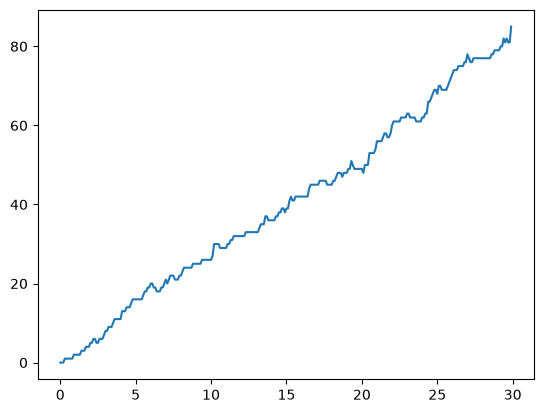

In [40]:
plt.plot(np.arange(0, 30, 0.1), ns)

## Ground-truth parameters and observation grid

Sets up the "known answer" used for the rest of the notebook's inference test:

- `times_obs`: 12 evenly-spaced observation times from 0 to 20 — this mimics a real experiment where the system is only observed at a handful of timepoints, not continuously.
- `theta_true`: the 4 rate parameters the simulator will be run with, and the values SMC-ABC will later try to recover from data alone. `initial_binding_rate` is kept small (`4e-5`) because it applies *per site* across the full ~50,000-site microtubule lattice — a more realistic value (e.g. `2.8`) makes each simulation far too slow for interactive testing (see [documentation/database_structure_review.md](documentation/database_structure_review.md)).

In [41]:
# small/fast test parameters -- theta_true[0]=2.8 (binding rate per site) over the
# full ~50,000-site microtubule makes the simulation extremely slow (see
# documentation/database_structure_review.md); 4e-5 keeps the total binding rate
# small enough to run in seconds while still exercising the full model, matching
# the values used in tests/code_walkthrough.ipynb.
times_obs = np.linspace(0.0, 20.0, 12)

theta_true = np.array([4e-5, 1.0, 10.0, 0.1], dtype=float)  # [initial_binding_rate, singly_bound_detachment_rate, base_double_attachment_rate, base_double_detachment_rate]

print("times_obs:", times_obs)
print("theta_true:", theta_true)

times_obs: [ 0.          1.81818182  3.63636364  5.45454545  7.27272727  9.09090909
 10.90909091 12.72727273 14.54545455 16.36363636 18.18181818 20.        ]
theta_true: [4.e-05 1.e+00 1.e+01 1.e-01]


## Run the full (non-gridded) simulation

Calls `run_gillespie_prc1` directly with `theta_true`, which returns *every* Gillespie event: `num_prc1` (the bound-count after each event) and `times` (the event times). This is the "raw" simulation output, as opposed to the grid-sampled version used everywhere else in the notebook — useful for inspecting individual event times, but not what SMC-ABC consumes.

In [42]:
initial_binding_rate, singly_bound_detachment_rate, base_double_attachment_rate, base_double_detachment_rate = theta_true
end_time = times_obs[-1]
num_prc1, times = run_gillespie_prc1(initial_binding_rate, singly_bound_detachment_rate, base_double_attachment_rate, base_double_detachment_rate, end_time)
print(num_prc1[:5])
print(times[:5])

[0, 1, 1, 2, 3]
[0.         0.4984381  0.49868819 1.22278328 1.32046305]


## Sanity-check the grid-sampled version

First asserts that `run_gillespie_prc1_on_grid` exists (a guard for whether an updated `run_gillespie.py` has actually been loaded), then runs it once at `theta_true` and samples the trajectory only at `times_obs`. `run_gillespie_prc1_on_grid` is what SMC-ABC actually calls internally — it avoids storing every event and avoids a `searchsorted` per path, so it's much cheaper to call thousands of times during inference. This cell just confirms it returns an array of the right shape (`len(times_obs)`,) with sensible values.

In [43]:
import run_gillespie as rg

assert hasattr(rg, "run_gillespie_prc1_on_grid"), (
    "run_gillespie_prc1_on_grid(...) not found in run_gillespie.py.\n"
    "Paste the updated function into run_gillespie.py first."
)

# Quick sanity run (single trajectory)
np.random.seed(123)  # spatial code uses np.random internally
y1 = rg.run_gillespie_prc1_on_grid(
    initial_binding_rate=float(theta_true[0]),
    singly_bound_detachment_rate=float(theta_true[1]),
    base_double_attachment_rate=float(theta_true[2]),
    base_double_detachment_rate=float(theta_true[3]),
    times_obs=times_obs
)

print("y1 shape:", y1.shape)
print("y1[:5]:", y1[:5])

y1 shape: (12,)
y1[:5]: [ 0  6  9 15 19]


## Build the synthetic "observed" data

`simulate_ensemble` repeats the grid-sampled simulation `n_runs` times at a fixed `theta` (each run reseeded independently), stacking the results into an array of shape `(n_runs, len(times_obs))`. Running it 10 times at `theta_true` produces `y_obs` — this stands in for real experimental data with run-to-run stochastic variability. The plot shows the mean trajectory ± standard deviation across the 10 runs. `y_obs` is what SMC-ABC will be asked to explain in the inference step below, *without* being told `theta_true`.

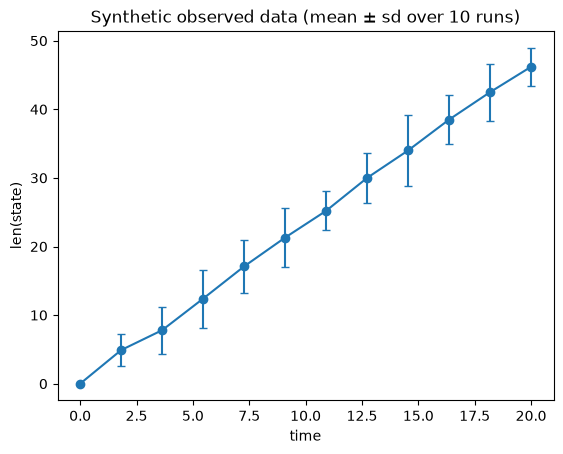

y_obs shape: (10, 12)


In [44]:
def simulate_ensemble(theta, n_runs, times_obs, seed=1):
    rng = np.random.default_rng(seed)
    paths = np.zeros((int(n_runs), len(times_obs)), dtype=float)
    for r in range(int(n_runs)):
        np.random.seed(int(rng.integers(0, 2**31 - 1)))
        paths[r] = rg.run_gillespie_prc1_on_grid(
            initial_binding_rate=float(theta[0]),
            singly_bound_detachment_rate=float(theta[1]),
            base_double_attachment_rate=float(theta[2]),
            base_double_detachment_rate=float(theta[3]),
            times_obs=times_obs
        )
    return paths

n_obs_runs = 10
y_obs = simulate_ensemble(theta_true, n_obs_runs, times_obs, seed=2026)

y_mean = y_obs.mean(axis=0)
y_sd = y_obs.std(axis=0, ddof=1)

plt.figure()
plt.errorbar(times_obs, y_mean, yerr=y_sd, fmt="o-", capsize=3)
plt.xlabel("time")
plt.ylabel("len(state)")
plt.title("Synthetic observed data (mean ± sd over 10 runs)")
plt.show()

print("y_obs shape:", y_obs.shape)

## Fuzz test: random parameters shouldn't crash

Draws 5 random parameter sets (uniformly, `initial_binding_rate_per_site` in a small range since it scales with the ~50,000 lattice sites) and just runs the full simulation on each without checking outputs — this is purely a crash/exception test, not a correctness check, to catch edge cases outside the narrow region around `theta_true`.

In [45]:
# test random params for bugs -- uses the current 4-parameter API (the old
# 3-parameter `k0` signature below was from a since-removed lumped model).
# initial_binding_rate_per_site is kept small since it scales with the ~50,000
# sites on the microtubule (see the "why is this slow" discussion in
# documentation/database_structure_review.md); the other rates don't have that
# multiplier so can be drawn from a wider range.
rng = np.random.default_rng(0)
for _ in range(5):
    initial_binding_rate_per_site = rng.uniform(1e-5, 1e-3)
    singly_bound_detachment_rate, base_double_attachment_rate, base_double_detachment_rate = rng.uniform(0.1, 10, size=3)
    run_gillespie_prc1(initial_binding_rate_per_site, singly_bound_detachment_rate,
                        base_double_attachment_rate, base_double_detachment_rate, end_time=20)
print("fuzz test completed without error")

fuzz test completed without error


## Regression check: `fast_hop()` crash

`fast_hop()` used to crash on this exact code path (see "Critical bug #1" in [documentation/database_structure_review.md](documentation/database_structure_review.md)). This cell re-runs that path directly (`enable_hopping="fast"`, cooperativity on) as a standing regression test — if it completes and prints a final value, the fix still holds. (An earlier version of this cell used the `%lprun` line-profiler magic; that's dropped here since `line_profiler` isn't a project dependency.)

In [46]:
# regression check: fast_hop() used to crash here (documentation/database_structure_review.md,
# Critical bug #1) -- this exercises that same code path directly. (The original
# %lprun profiling magic needed the line_profiler package, which isn't a project
# dependency, so it's replaced with a plain call.)
ns_fast_hop = run_gillespie_prc1_on_grid(4e-5, 1, 10, 0.1, np.arange(0, 10, 0.1), cooperativity_energy=10, enable_cooperativity=True, enable_hopping="fast", max_steps=2000)
print("fast_hop regression check completed, final value:", ns_fast_hop[-1])

fast_hop regression check completed, final value: 23


## Plot the full-resolution trajectory

Replots `num_prc1` vs. `times` from the earlier full (non-gridded) simulation cell, this time as a step-like event trajectory rather than the grid-sampled version plotted near the top of the notebook.

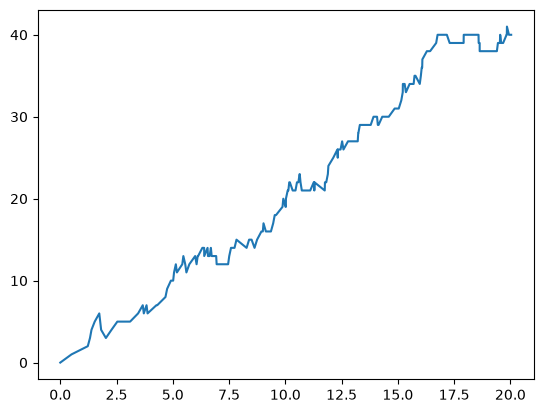

In [47]:
plt.plot(times, num_prc1)

---
# Part 2: Bayesian inference with SMC-ABC

Everything above tested the simulator itself. From here on, the notebook treats `theta_true` as unknown, uses only the synthetic `y_obs` built earlier, and tries to recover the 4 rate parameters with SMC-ABC — a likelihood-free method that accepts/reweights candidate parameters based on how closely simulated data matches the observed data, rather than an exact likelihood.

## Load `smc_abc_prc1`

Loads the inference entry point `smc_abc_prc1` from [smc-abc.py](smc-abc.py) via `runpy`, with asserts to fail fast if the file is missing or the function name has changed.

In [48]:
smc_path = "smc-abc.py"
assert os.path.exists(smc_path), f"Can't find {smc_path} in: {os.getcwd()}"

smc_mod = runpy.run_path(smc_path)
assert "smc_abc_prc1" in smc_mod, "smc_abc_prc1 not found in smc-abc.py"
smc_abc_prc1 = smc_mod["smc_abc_prc1"]

print("Loaded smc_abc_prc1 from", smc_path)

Loaded smc_abc_prc1 from smc-abc.py


## Run SMC-ABC

Infers the posterior over `theta` given `y_obs`. Key inputs:

- **Prior**: parameters are modeled in log-space as `phi = log(theta) ~ Normal(phi_mu, phi_sd)`, with `phi_mu = log(theta_true)` (centering the prior on the true value, since this is a controlled test) and `phi_sd = 0.4` per parameter.
- **`P=15, G=2, pool=80`**: 15 particles, run for 2 SMC generations, drawing an 80-candidate pool per generation.
- **`n_reps=2`**: each candidate `theta` is simulated twice and summarized (mean + variance across reps) before comparing to `y_obs`, since a single stochastic run is a noisy summary.
- **`eps_quantile=70.0`**: each generation keeps roughly the closest 70% of candidates (by summary-statistic distance to `y_obs`), shrinking the acceptance threshold `eps` over generations.
- **`n_jobs=-1`**: parallelizes candidate evaluation across all CPU cores via `joblib`.

`res.particles_phi` holds the final weighted particle cloud (in log-space) and `res.weights` their importance weights; `theta_particles = exp(res.particles_phi)` converts back to the original parameter scale. `theta_post_mean` is the weighted posterior mean, printed alongside `theta_true` for a quick eyeball comparison.

In [49]:
phi_mu = np.log(theta_true)
phi_sd = np.array([0.4, 0.4, 0.4, 0.4], dtype=float)  # widen if acceptance is too low

res = smc_abc_prc1(
    times_obs=times_obs,
    y_obs=y_obs,
    phi_mu=phi_mu,
    phi_sd=phi_sd,
    P=15,
    G=2,
    pool=80,
    n_reps=2,
    eps_quantile=70.0,
    cov_scale=1.5,
    seed=42,
    n_jobs=-1,
    batch_factor=2
)

theta_particles = np.exp(res.particles_phi)
w = res.weights
theta_post_mean = (theta_particles * w[:, None]).sum(axis=0)

print("eps history:", res.eps_history)
print("true theta:", theta_true)
print("posterior mean:", theta_post_mean)

eps history: [45.59291963658013, 43.17164145844872]
true theta: [4.e-05 1.e+00 1.e+01 1.e-01]
posterior mean: [3.73905410e-05 9.43217690e-01 8.29324952e+00 1.05506802e-01]


## Posterior marginals: histograms

For each of the 4 parameters, plots a weighted histogram of the posterior particles (`theta_particles[:, j]`, weighted by `w`) with a dashed line at the true value. If SMC-ABC worked, the bulk of each histogram's mass should sit close to its dashed line.

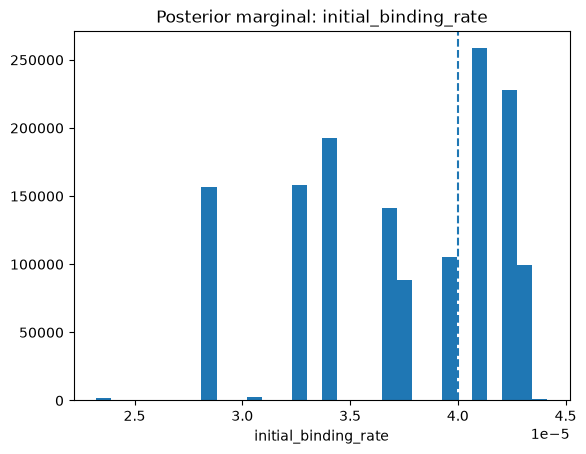

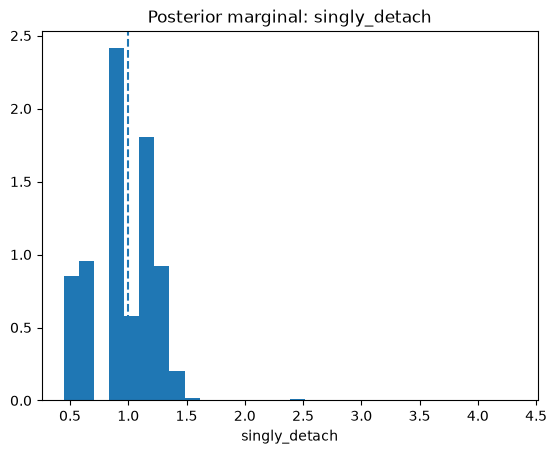

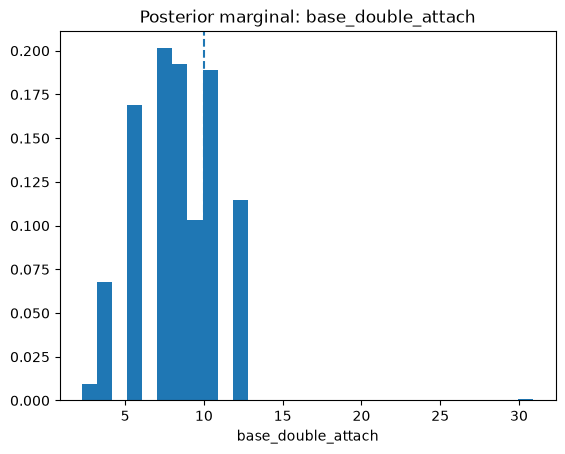

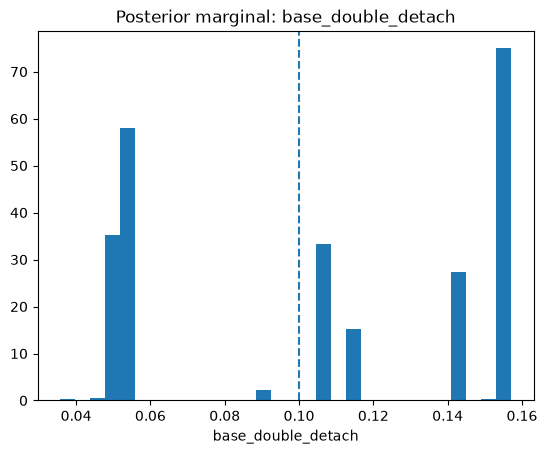

In [50]:
names = ["initial_binding_rate", "singly_detach", "base_double_attach", "base_double_detach"]

for j in range(4):
    plt.figure()
    plt.hist(theta_particles[:, j], bins=30, weights=w, density=True)
    plt.axvline(theta_true[j], linestyle="--")
    plt.xlabel(names[j])
    plt.title(f"Posterior marginal: {names[j]}")
    plt.show()

## Prior vs. posterior: KDE comparison

Draws a large sample (`n_prior=50000`) from the prior in log-space and exponentiates it to get `theta_prior`, then fits a Gaussian KDE to both the prior sample and the (weighted) posterior particles for each parameter. Plotting them together shows how much the data narrowed/shifted each parameter's distribution relative to the prior — a bigger gap between the two curves (with the posterior tightening around the true-value dashed line) indicates the data was informative about that parameter.

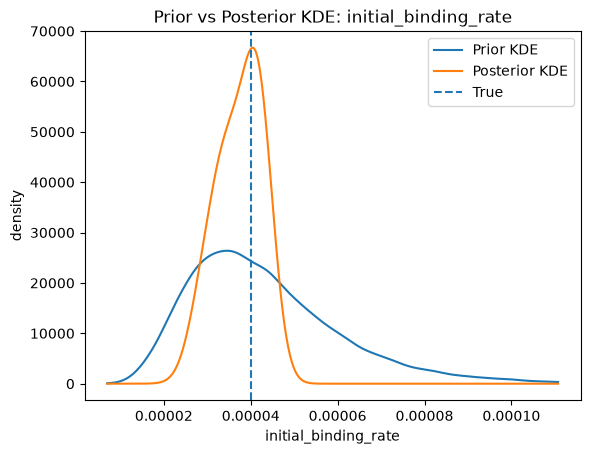

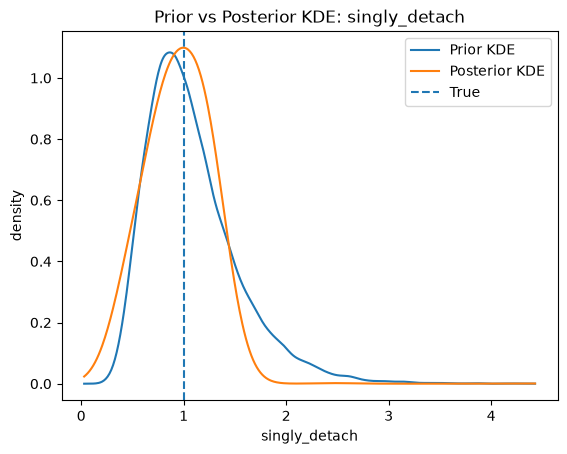

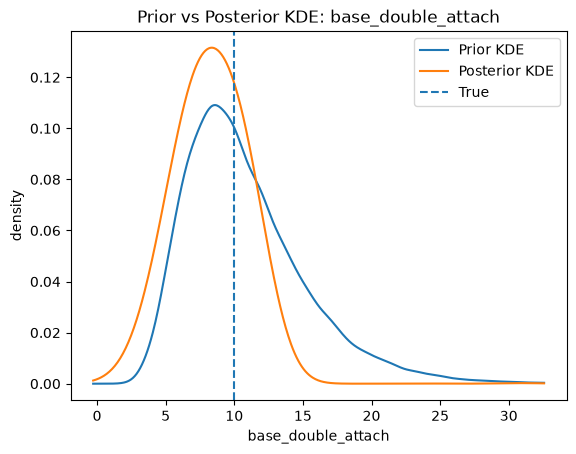

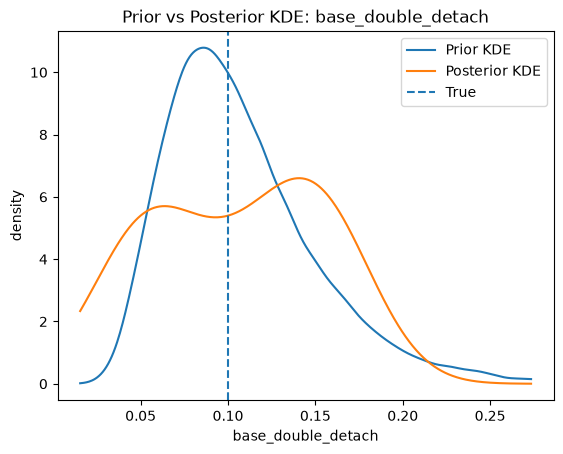

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

theta_post = np.exp(res.particles_phi)   # (P, 4)
w_post = res.weights.astype(float)
w_post = w_post / w_post.sum()

n_prior = 50000
rng = np.random.default_rng(123)

phi_mu_arr = np.asarray(phi_mu, dtype=float)
phi_sd_arr = np.asarray(phi_sd, dtype=float)

phi_prior = rng.normal(loc=phi_mu_arr, scale=phi_sd_arr, size=(n_prior, 4))
theta_prior = np.exp(phi_prior) 

names = ["initial_binding_rate", "singly_detach", "base_double_attach", "base_double_detach"]

for j in range(4):
    x_post = theta_post[:, j]
    x_prior = theta_prior[:, j]
    kde_post = gaussian_kde(x_post, weights=w_post)
    kde_prior = gaussian_kde(x_prior)
    lo = min(np.quantile(x_prior, 0.01), np.quantile(x_post, 0.01))
    hi = max(np.quantile(x_prior, 0.99), np.quantile(x_post, 0.99))
    pad = 0.10 * (hi - lo + 1e-12)
    xs = np.linspace(lo - pad, hi + pad, 500)

    plt.figure()
    plt.plot(xs, kde_prior(xs), label="Prior KDE")
    plt.plot(xs, kde_post(xs), label="Posterior KDE")
    plt.axvline(theta_true[j], linestyle="--", label="True")
    plt.xlabel(names[j])
    plt.ylabel("density")
    plt.title(f"Prior vs Posterior KDE: {names[j]}")
    plt.legend()
    plt.show()